In [43]:
import pandas as pd

# Load datasets
MatchHomeTeamInfo = pd.read_parquet(
    "data/processed/MatchHomeTeamInfo.parquet"
)

MatchAwayTeamInfo = pd.read_parquet(
    "data/processed/MatchAwayTeamInfo.parquet"
)

MatchTournamentInfo = pd.read_parquet(
    "data/processed/MatchTournamentInfo.parquet"
)

tennis_power = pd.read_parquet(
    "data/processed/tennis_power.parquet"
)


# Question 13

To determine the distribution of left-handed and right-handed players, the home and away player datasets were combined. Duplicate players were removed using player_id to ensure that each player was counted only once. The plays column was then used to classify players as left-handed or right-handed.

In [49]:
players = pd.concat([
    MatchHomeTeamInfo[["player_id", "plays"]],
    MatchAwayTeamInfo[["player_id", "plays"]]
])

In [50]:
players = players.drop_duplicates(subset="player_id")

In [54]:
print("Number of players:", len(players))
print("Unique player IDs:", players["player_id"].nunique())

print("\nPlays:")
print(players["plays"].value_counts(dropna=False))

Number of players: 2644
Unique player IDs: 2644

Plays:
plays
NaN             1498
right-handed    1013
left-handed      133
Name: count, dtype: int64


In [51]:
players["plays"].value_counts()

plays
right-handed    1013
left-handed      133
Name: count, dtype: int64

In [52]:
print("Percentage")
players["plays"].value_counts(normalize=True) * 100

Percentage


plays
right-handed    88.394415
left-handed     11.605585
Name: proportion, dtype: float64

**Interpretation** 

 The results show that right-handed players are considerably more common in the dataset. Approximately 88.4% of the players are right-handed, compared with only 11.6% who are left-handed.

Handedness information was missing for 1,498 out of 2,644 players (56.7%), so the percentages were calculated only for players with available data.

# Question 14

What is the most common type of surface used in tournaments?

To identify the most common surface type, the ground_type column from the tournament information dataset was used. Since each tournament can contain multiple matches, duplicate tournament records were removed based on tournament_id so that each tournament was counted only once.

In [7]:
tournaments = MatchTournamentInfo[
    ["tournament_id", "ground_type"]
].drop_duplicates()

surface_distribution = tournaments["ground_type"].value_counts()

print(surface_distribution)

ground_type
Hardcourt outdoor    239
Red clay             187
Hardcourt indoor      85
Red clay indoor        8
Grass                  8
Carpet indoor          5
Synthetic outdoor      4
Green clay             1
Name: count, dtype: int64


In [8]:
print("Most common surface:", surface_distribution.idxmax())

Most common surface: Hardcourt outdoor


# Question 15

How many distinct countries are represented in the dataset?

In [44]:
print(MatchHomeTeamInfo["country"].head())
print(MatchAwayTeamInfo["country"].head())

0     France
1     France
2    Croatia
3        USA
4     France
Name: country, dtype: str
0    Canada
1     Italy
2     Spain
3    France
4    France
Name: country, dtype: str


In [45]:
print(
    "Home players - distinct countries:",
    MatchHomeTeamInfo["country"].nunique()
)

print(
    "Away players - distinct countries:",
    MatchAwayTeamInfo["country"].nunique()
)

Home players - distinct countries: 99
Away players - distinct countries: 96


In [46]:
countries = pd.concat([
    MatchHomeTeamInfo["country"],
    MatchAwayTeamInfo["country"]
])

distinct_countries = countries.dropna().nunique()

print("Number of distinct countries:", distinct_countries)

Number of distinct countries: 101


Which countries have the largest number of player records in the dataset?

In [47]:
country_counts = (
    countries
    .dropna()
    .value_counts()
    .head(10)
)

print(country_counts)

country
France            4270
Italy             4057
USA               3644
Russia            2557
Germany           2297
Argentina         2275
Spain             2145
Japan             2132
Australia         1714
United Kingdom    1553
Name: count, dtype: int64


# Question 16

Which player has the highest winning percentage against top 10 ranked opponents?

In [3]:
import pandas as pd

MatchHomeTeamInfo = pd.read_parquet(
    "data/processed/MatchHomeTeamInfo.parquet"
)

MatchAwayTeamInfo = pd.read_parquet(
    "data/processed/MatchAwayTeamInfo.parquet"
)

MatchEventInfo = pd.read_parquet(
    "data/processed/match_event_info.parquet"
)

print("Home rank sample:")
print(
    MatchHomeTeamInfo[
        ["match_id", "player_id", "full_name", "current_rank"]
    ].head(10)
)

print("\nAway rank sample:")
print(
    MatchAwayTeamInfo[
        ["match_id", "player_id", "full_name", "current_rank"]
    ].head(10)
)

print("\nWinner codes:")
print(
    MatchEventInfo["winner_code"]
    .value_counts(dropna=False)
    .sort_index()
)

Home rank sample:
   match_id  player_id              full_name  current_rank
0  11998445     287803         Cazaux, Arthur          86.0
1  11998446      62790    Lestienne, Constant          99.0
2  11998447      64580           Ćorić, Borna          31.0
3  11998448     131442          Mmoh, Michael         122.0
4  11998449      22218          Paire, Benoit         110.0
5  11998450     117916      Shapovalov, Denis         120.0
6  11998451     264344  Shevchenko, Alexander          47.0
7  11998456     264344  Shevchenko, Alexander          47.0
8  11998459     283070           Rune, Holger           7.0
9  11998666      39712          Saville, Luke         295.0

Away rank sample:
   match_id  player_id               full_name  current_rank
0  11998445     192013  Auger-Aliassime, Felix          30.0
1  11998446     273680          Flavio Cobolli          69.0
2  11998447      77223         Martinez, Pedro         101.0
3  11998448      88992       Muller, Alexandre          81.

Concern: Before calculating the winning percentage, I needed to make sure that each match was counted only once. Therefore, I first checked whether match_id was unique in the three datasets used for the analysis.

In [4]:
check = MatchEventInfo[
    ["match_id", "winner_code"]
].merge(
    MatchHomeTeamInfo[
        ["match_id", "full_name", "current_rank"]
    ],
    on="match_id"
).merge(
    MatchAwayTeamInfo[
        ["match_id", "full_name", "current_rank"]
    ],
    on="match_id",
    suffixes=("_home", "_away")
)

print(check.head(10).to_string(index=False))

 match_id  winner_code      full_name_home  current_rank_home         full_name_away  current_rank_away
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998446          2.0 Lestienne, Constant               99.0         Flavio Cobolli               69.0
 11998446          2.0 Lestienne, Constant               99.0         Flavio Cobolli               69.0
 11998446          2.0 Lestienne, Constant               99.0         Flavio Cobolli               69.0
 11998446          2.0 Lestienne, Constant               99.0         Flavio Cobolli               69.0
 11998447          1.0        Ćorić, Borna               31.0   

The results showed that match_id was not unique in any of the three datasets. Therefore, I needed to investigate the reason for these duplicate records before removing them.


Concern: I needed to determine whether the duplicated match_id values represented different matches or repeated records of the same match. Removing duplicates without checking this could lead to loss of important information.

In [8]:
print(
    MatchEventInfo[
        MatchEventInfo["match_id"] == 11998445
    ].to_string(index=False)
)

print(
    MatchHomeTeamInfo[
        MatchHomeTeamInfo["match_id"] == 11998445
    ].to_string(index=False)
)

print(
    MatchAwayTeamInfo[
        MatchAwayTeamInfo["match_id"] == 11998445
    ].to_string(index=False)
)

 match_id  first_to_serve home_team_seed away_team_seed custom_id  winner_code  default_period_count  start_datetime             match_slug  final_result_only     date
 11998445             1.0            NaN              3 nPBbsdgpc          2.0                     3      1706810400 cazaux-auger-aliassime              False 20240201
 11998445             1.0            NaN              3 nPBbsdgpc          2.0                     3      1706810400 cazaux-auger-aliassime              False 20240202
 match_id      name          slug gender  user_count residence          birthplace  height  weight        plays turned_pro  current_prize  total_prize  player_id  current_rank name_code country      full_name     date
 11998445 Cazaux A. cazaux-arthur      M        4481       NaN Montpellier, France    1.83     NaN right-handed        NaN       233290.0     643582.0     287803          86.0       CAZ  France Cazaux, Arthur 20240201
 11998445 Cazaux A. cazaux-arthur      M        4481       N

The investigation showed that the same match was recorded on different dates, while the players, rankings, match result, and other match information remained unchanged. Therefore, these records represented repeated observations of the same match rather than different matches.

Concern: Since the duplicated records represented the same match, I needed to keep only one record for each match_id to ensure that every match was counted once in the analysis.

In [9]:
MatchEventInfo_unique = MatchEventInfo.drop_duplicates(
    subset="match_id"
)

MatchHomeTeamInfo_unique = MatchHomeTeamInfo.drop_duplicates(
    subset="match_id"
)

MatchAwayTeamInfo_unique = MatchAwayTeamInfo.drop_duplicates(
    subset="match_id"
)

After removing duplicate records based on match_id, each match was represented only once in the datasets. This prevents repeated matches from affecting the calculation of winning percentages.

Concern: To calculate each player's winning percentage, I needed to determine which player won each match. Therefore, I examined the winner_code variable.

In [10]:
print(
    MatchEventInfo["winner_code"]
    .value_counts(dropna=False)
    .sort_index()
)

winner_code
1.0    16552
2.0    15452
NaN     3049
Name: count, dtype: int64


The winner_code variable contains two main values. A value of 1 indicates that the home player won, while a value of 2 indicates that the away player won. Missing values were also present in the dataset.

Concern: After removing duplicate records, I needed to combine the home-player, away-player, and match-result information into a single dataset. This allows each match to contain the identities and rankings of both players, as well as the winner.

In [11]:
matches = (
    MatchEventInfo_unique[
        ["match_id", "winner_code"]
    ]
    .merge(
        MatchHomeTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner"
    )
    .merge(
        MatchAwayTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner",
        suffixes=("_home", "_away")
    )
)

print("Shape:", matches.shape)
print(matches.head())

Shape: (9882, 8)
   match_id  winner_code  player_id_home       full_name_home  \
0  11998445          2.0          287803       Cazaux, Arthur   
1  11998446          2.0           62790  Lestienne, Constant   
2  11998447          1.0           64580         Ćorić, Borna   
3  11998448          1.0          131442        Mmoh, Michael   
4  11998449          2.0           22218        Paire, Benoit   

   current_rank_home  player_id_away          full_name_away  \
0               86.0          192013  Auger-Aliassime, Felix   
1               99.0          273680          Flavio Cobolli   
2               31.0           77223         Martinez, Pedro   
3              122.0           88992       Muller, Alexandre   
4              110.0          248846           Mayot, Harold   

   current_rank_away  
0               30.0  
1               69.0  
2              101.0  
3               81.0  
4              132.0  


Concern: I needed to combine the match result with the information of both players so that each match could be analyzed based on the players' identities and rankings.

In [13]:
matches = (
    MatchEventInfo_unique[
        ["match_id", "winner_code"]
    ]
    .merge(
        MatchHomeTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner"
    )
    .merge(
        MatchAwayTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner",
        suffixes=("_home", "_away")
    )
)

The three datasets were successfully merged into a single match-level dataset containing 9,882 matches. Each record includes the home and away players, their current rankings, and the match winner.

Concern: The question specifically asks about winning performance against Top 10 opponents. Therefore, I needed to identify matches in which at least one of the two players was ranked within the Top 10.

In [14]:
top10_matches = matches[
    (matches["current_rank_home"] <= 10) |
    (matches["current_rank_away"] <= 10)
].copy()

print("Total matches:", len(matches))
print("Matches involving a Top 10 player:", len(top10_matches))

print(top10_matches[
    [
        "match_id",
        "full_name_home",
        "current_rank_home",
        "full_name_away",
        "current_rank_away",
        "winner_code"
    ]
].head(10))

Total matches: 9882
Matches involving a Top 10 player: 222
     match_id          full_name_home  current_rank_home      full_name_away  \
8    11998459            Rune, Holger                7.0  Llamas Ruiz, Pablo   
53   12002055       Ostapenko, Jelena               10.0       Tauson, Clara   
154  12021512  Bielinskyi, Viacheslav              499.0       Fritz, Taylor   
224  12024041           Fomin, Sergey              656.0     Hurkacz, Hubert   
265  11998454            Rune, Holger                7.0       Mmoh, Michael   
280  12002059       Ostapenko, Jelena               10.0      Burrage, Jodie   
285  12021514        Krutykh, Oleksii              392.0       Fritz, Taylor   
293  12024039      Sultanov, Khumoyun              332.0     Hurkacz, Hubert   
394  12028119        Orlov, Vladyslav              606.0       Fritz, Taylor   
407  11998457            Rune, Holger                7.0        Ćorić, Borna   

     current_rank_away  winner_code  
8                151.0

Concern: Identifying matches involving a Top 10 player is not enough. I needed to determine which player was actually facing the Top 10 opponent in each match. Therefore, the data was transformed from a match-based structure into a player-versus-opponent structure.

In [15]:
top10_opponent_matches = []

for _, row in matches.iterrows():

    # Home player faced a Top 10 opponent
    if row["current_rank_away"] <= 10:
        top10_opponent_matches.append({
            "match_id": row["match_id"],
            "player_id": row["player_id_home"],
            "player": row["full_name_home"],
            "opponent_id": row["player_id_away"],
            "opponent": row["full_name_away"],
            "opponent_rank": row["current_rank_away"],
            "winner_code": row["winner_code"],
            "player_side": "home"
        })

    # Away player faced a Top 10 opponent
    if row["current_rank_home"] <= 10:
        top10_opponent_matches.append({
            "match_id": row["match_id"],
            "player_id": row["player_id_away"],
            "player": row["full_name_away"],
            "opponent_id": row["player_id_home"],
            "opponent": row["full_name_home"],
            "opponent_rank": row["current_rank_home"],
            "winner_code": row["winner_code"],
            "player_side": "away"
        })

top10_opponent_matches = pd.DataFrame(top10_opponent_matches)

print("Shape:", top10_opponent_matches.shape)
print(top10_opponent_matches.head(10))

Shape: (237, 8)
   match_id  player_id                  player  opponent_id  \
0  11998459     264358      Llamas Ruiz, Pablo       283070   
1  12002055     252168           Tauson, Clara        64496   
2  12021512     339443  Bielinskyi, Viacheslav       136042   
3  12024041     198223           Fomin, Sergey       158896   
4  11998454     131442           Mmoh, Michael       283070   
5  12002059     172590          Burrage, Jodie        64496   
6  12021514     232615        Krutykh, Oleksii       136042   
7  12024039     149100      Sultanov, Khumoyun       158896   
8  12028119     154570        Orlov, Vladyslav       136042   
9  11998457      64580            Ćorić, Borna       283070   

            opponent  opponent_rank  winner_code player_side  
0       Rune, Holger            7.0          1.0        away  
1  Ostapenko, Jelena           10.0          1.0        away  
2      Fritz, Taylor           10.0          NaN        home  
3    Hurkacz, Hubert            8.0   

Concern: After identifying each player's matches against Top 10 opponents, I needed to determine whether the player won or lost each match. Since winner_code identifies the winning side rather than the winning player directly, the player's side (home or away) was used to determine the result.

In [16]:
def get_result(row):
    if pd.isna(row["winner_code"]):
        return "Unknown"
    
    if row["player_side"] == "home" and row["winner_code"] == 1:
        return "Win"
    
    if row["player_side"] == "away" and row["winner_code"] == 2:
        return "Win"
    
    return "Loss"


top10_opponent_matches["result"] = (
    top10_opponent_matches.apply(get_result, axis=1)
)

print(
    top10_opponent_matches[
        ["player", "opponent", "opponent_rank",
         "player_side", "winner_code", "result"]
    ].head(15)
)

                       player           opponent  opponent_rank player_side  \
0          Llamas Ruiz, Pablo       Rune, Holger            7.0        away   
1               Tauson, Clara  Ostapenko, Jelena           10.0        away   
2      Bielinskyi, Viacheslav      Fritz, Taylor           10.0        home   
3               Fomin, Sergey    Hurkacz, Hubert            8.0        home   
4               Mmoh, Michael       Rune, Holger            7.0        away   
5              Burrage, Jodie  Ostapenko, Jelena           10.0        away   
6            Krutykh, Oleksii      Fritz, Taylor           10.0        home   
7          Sultanov, Khumoyun    Hurkacz, Hubert            8.0        home   
8            Orlov, Vladyslav      Fritz, Taylor           10.0        home   
9                Ćorić, Borna       Rune, Holger            7.0        away   
10  Pavlyuchenkova, Anastasia  Ostapenko, Jelena            9.0        away   
11     Alexandrova, Ekaterina  Ostapenko, Jelena    

In [17]:
print("\nResult distribution:")
print(
    top10_opponent_matches["result"]
    .value_counts(dropna=False)
)


Result distribution:
result
Loss       160
Win         66
Unknown     11
Name: count, dtype: int64


Concern: I needed to calculate the winning percentage of each player against Top 10 opponents. Since 11 matches had missing winner information, these observations were excluded from the calculation rather than being treated as wins or losses.

In [18]:
top10_known = top10_opponent_matches[
    top10_opponent_matches["result"].isin(["Win", "Loss"])
].copy()

In [19]:
player_performance = (
    top10_known
    .groupby("player")
    .agg(
        top10_matches=("result", "count"),
        wins=("result", lambda x: (x == "Win").sum())
    )
    .reset_index()
)

In [20]:
player_performance["winning_percentage"] = (
    player_performance["wins"]
    / player_performance["top10_matches"]
    * 100
)

In [21]:
player_performance = player_performance.sort_values(
    "winning_percentage",
    ascending=False
)

print(player_performance.head(10))

                 player  top10_matches  wins  winning_percentage
2      Altmaier, Daniel              1     1               100.0
12    Bublik, Alexander              1     1               100.0
5      Avanesyan, Elina              1     1               100.0
130        Ćorić, Borna              1     1               100.0
114     Tsurenko, Lesia              1     1               100.0
64        Mensik, Jakub              1     1               100.0
66      Michelsen, Alex              1     1               100.0
43   Kalinina, Anhelina              1     1               100.0
46    Kerber, Angelique              1     1               100.0
40         Humbert, Ugo              3     3               100.0


Concern: The initial results showed that several players had a 100% winning percentage against Top 10 opponents, but many of them had played only one match. A winning percentage based on a single match may not provide a reliable comparison. Therefore, I introduced a minimum-match threshold and considered only players who had faced Top 10 opponents at least five times.

In [22]:
qualified_players = player_performance[
    player_performance["top10_matches"] >= 5
].copy()

qualified_players = qualified_players.sort_values(
    "winning_percentage",
    ascending=False
)

print(qualified_players.head(10))

                player  top10_matches  wins  winning_percentage
22    Dimitrov, Grigor              6     3                50.0
6   Azarenka, Victoria              5     2                40.0


Grigor Dimitrov had the highest winning percentage against Top 10 opponents among players with at least five recorded matches, winning 50% of his matches (3 out of 6).

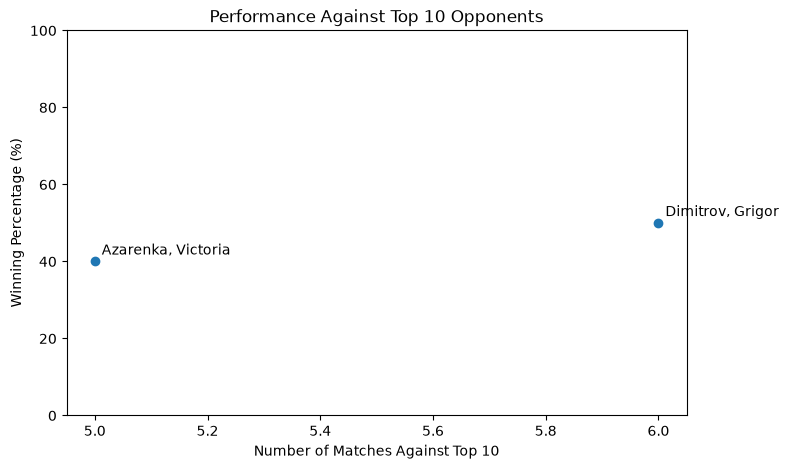

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    qualified_players["top10_matches"],
    qualified_players["winning_percentage"]
)

for _, row in qualified_players.iterrows():
    plt.annotate(
        row["player"],
        (row["top10_matches"], row["winning_percentage"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Number of Matches Against Top 10")
plt.ylabel("Winning Percentage (%)")
plt.title("Performance Against Top 10 Opponents")
plt.ylim(0, 100)

plt.show()

# Question 17

What is the average number of breaks of serve per match?

In [25]:
import pandas as pd

tennis_power = pd.read_parquet(
    "data/processed/tennis_power.parquet"
)

print("Shape:", tennis_power.shape)
print(tennis_power.head())

Shape: (469677, 6)
   match_id  set_num  game_num  value  break_occurred      date
0  11998445        1         1 -52.80           False  20240201
1  11998445        1         2  48.14           False  20240201
2  11998445        1         3 -51.62           False  20240201
3  11998445        1         4  10.00           False  20240201
4  11998445        1         5  26.60            True  20240201


**Check duplicates**

In [26]:
print(
    "Exact duplicate rows:",
    tennis_power.duplicated().sum()
)

Exact duplicate rows: 0


In [27]:
print(
    "Duplicate games:",
    tennis_power.duplicated(
        subset=["match_id", "set_num", "game_num"]
    ).sum()
)

Duplicate games: 239096


In [28]:
print(
    tennis_power.groupby("date")["match_id"]
    .nunique()
)

date
20240201    271
20240202    254
20240203    352
20240204    412
20240205    410
20240206    431
20240207    415
20240208    318
20240209    218
20240210    251
20240211    235
20240212    334
20240213    454
20240214    495
20240215    431
20240216    268
20240217    223
20240218    196
20240219    406
20240220    410
20240221    513
20240222    398
20240223    234
20240224    247
20240225    250
20240226    380
20240227    495
20240228    643
20240229    438
20240301    237
20240302    178
20240303    259
20240304    383
20240305    546
20240306    572
20240307    440
20240308    273
20240309    226
20240310    346
20240311    548
20240312    731
20240313    766
20240314    587
20240315    310
20240316    145
20240317    249
20240318    417
20240319    617
20240320    631
20240321    497
20240322    277
20240323    235
20240324    300
20240325    393
20240326    531
20240327    514
20240328    339
20240329    202
20240330    230
20240331    363
Name: match_id, dtype: int64


In [29]:
print(
    tennis_power["date"]
    .value_counts()
    .sort_index()
)

date
20240201     5894
20240202     5591
20240203     7516
20240204     8520
20240205     8525
20240206     8975
20240207     8723
20240208     6682
20240209     4710
20240210     5241
20240211     4595
20240212     6893
20240213     9426
20240214    10634
20240215     9264
20240216     5772
20240217     4654
20240218     3852
20240219     8262
20240220     8262
20240221    10623
20240222     8321
20240223     5069
20240224     5199
20240225     4834
20240226     7295
20240227     9884
20240228    13444
20240229     9151
20240301     5059
20240302     3698
20240303     5029
20240304     7255
20240305    10739
20240306    11691
20240307     9213
20240308     5933
20240309     4914
20240310     6898
20240311    10708
20240312    14737
20240313    15927
20240314    12179
20240315     6492
20240316     3062
20240317     4949
20240318     8311
20240319    12567
20240320    13121
20240321    10511
20240322     5760
20240323     4956
20240324     6175
20240325     8090
20240326    11114
20240

In [30]:
match_dates = (
    tennis_power
    .groupby("match_id")["date"]
    .nunique()
)

print(match_dates.describe())

print(
    "\nMatches with multiple dates:",
    (match_dates > 1).sum()
)

print(
    "\nMatches with only one date:",
    (match_dates == 1).sum()
)

count    11121.000000
mean         2.043341
std          0.419951
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: date, dtype: float64

Matches with multiple dates: 10379

Matches with only one date: 742


In [31]:
multi_date_matches = match_dates[match_dates > 1]

sample_match = multi_date_matches.index[0]

print(
    tennis_power[
        tennis_power["match_id"] == sample_match
    ].to_string(index=False)
)

 match_id  set_num  game_num  value  break_occurred     date
 11998445        1         1 -52.80           False 20240201
 11998445        1         2  48.14           False 20240201
 11998445        1         3 -51.62           False 20240201
 11998445        1         4  10.00           False 20240201
 11998445        1         5  26.60            True 20240201
 11998445        1         6  10.00           False 20240201
 11998445        1         7 -10.00           False 20240201
 11998445        1         8 -59.30            True 20240201
 11998445        1         9 -33.02           False 20240201
 11998445        1        10  36.82           False 20240201
 11998445        1        11 -26.36           False 20240201
 11998445        1        12 -32.98            True 20240201
 11998445        2         1 -12.60           False 20240201
 11998445        2         2  10.00           False 20240201
 11998445        2         3  53.10            True 20240201
 11998445        2      

In [32]:
print(match_dates.describe())

print(
    "\nMatches with multiple dates:",
    (match_dates > 1).sum()
)

print(
    "\nMatches with only one date:",
    (match_dates == 1).sum()
)

count    11121.000000
mean         2.043341
std          0.419951
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: date, dtype: float64

Matches with multiple dates: 10379

Matches with only one date: 742


In [33]:
snapshot_quality = (
    tennis_power
    .groupby(["match_id", "date"])
    .agg(
        games=("game_num", "count"),
        breaks=("break_occurred", "sum")
    )
    .reset_index()
)

print(snapshot_quality.head(20))

    match_id      date  games  breaks
0   11998445  20240201     33       9
1   11998445  20240202     33       9
2   11998446  20240201     17       6
3   11998446  20240202     17       6
4   11998447  20240201     16       4
5   11998447  20240202     16       4
6   11998448  20240201     20       6
7   11998449  20240201     17       3
8   11998450  20240201     29       4
9   11998451  20240201     30       3
10  11998452  20240202     19       2
11  11998452  20240203     19       2
12  11998453  20240202     19       7
13  11998453  20240203     19       7
14  11998454  20240202     23       3
15  11998454  20240203     23       3
16  11998455  20240204     29       6
17  11998455  20240205     29       6
18  11998456  20240201     29       7
19  11998456  20240202     29       7


In [34]:
game_consistency = (
    tennis_power
    .groupby(["match_id", "set_num", "game_num"])
    .agg(
        value_count=("value", "nunique"),
        break_count=("break_occurred", "nunique")
    )
    .reset_index()
)

print(
    "Games with different values across dates:",
    (game_consistency["value_count"] > 1).sum()
)

print(
    "Games with different break status across dates:",
    (game_consistency["break_count"] > 1).sum()
)

Games with different values across dates: 9062
Games with different break status across dates: 14033


In [35]:
snapshot_comparison = (
    tennis_power
    .groupby(["match_id", "date"])
    .agg(
        games=("game_num", "count"),
        breaks=("break_occurred", "sum")
    )
    .reset_index()
)

snapshot_comparison["date"] = pd.to_datetime(
    snapshot_comparison["date"].astype(str)
)

snapshot_comparison = snapshot_comparison.sort_values(
    ["match_id", "date"]
)

snapshot_comparison["snapshot_number"] = (
    snapshot_comparison
    .groupby("match_id")
    .cumcount() + 1
)

print(snapshot_comparison.head(20))

    match_id       date  games  breaks  snapshot_number
0   11998445 2024-02-01     33       9                1
1   11998445 2024-02-02     33       9                2
2   11998446 2024-02-01     17       6                1
3   11998446 2024-02-02     17       6                2
4   11998447 2024-02-01     16       4                1
5   11998447 2024-02-02     16       4                2
6   11998448 2024-02-01     20       6                1
7   11998449 2024-02-01     17       3                1
8   11998450 2024-02-01     29       4                1
9   11998451 2024-02-01     30       3                1
10  11998452 2024-02-02     19       2                1
11  11998452 2024-02-03     19       2                2
12  11998453 2024-02-02     19       7                1
13  11998453 2024-02-03     19       7                2
14  11998454 2024-02-02     23       3                1
15  11998454 2024-02-03     23       3                2
16  11998455 2024-02-04     29       6          

In [36]:
snapshot_counts = (
    snapshot_comparison
    .groupby("match_id")
    .size()
)

print(snapshot_counts.value_counts().sort_index())

1     742
2    9163
3    1208
4       8
Name: count, dtype: int64


In [37]:
latest_vs_first = (
    snapshot_comparison
    .groupby("match_id")
    .agg(
        first_games=("games", "first"),
        latest_games=("games", "last"),
        first_breaks=("breaks", "first"),
        latest_breaks=("breaks", "last")
    )
)

latest_vs_first["games_changed"] = (
    latest_vs_first["first_games"] !=
    latest_vs_first["latest_games"]
)

latest_vs_first["breaks_changed"] = (
    latest_vs_first["first_breaks"] !=
    latest_vs_first["latest_breaks"]
)

print(
    "Matches where number of games changed:",
    latest_vs_first["games_changed"].sum()
)

print(
    "Matches where number of breaks changed:",
    latest_vs_first["breaks_changed"].sum()
)

Matches where number of games changed: 163
Matches where number of breaks changed: 1377


In [38]:
tennis_power_clean = (
    tennis_power
    .sort_values("date")
    .drop_duplicates(
        subset=["match_id", "set_num", "game_num"],
        keep="last"
    )
)

print("Original rows:", len(tennis_power))
print("Clean rows:", len(tennis_power_clean))

Original rows: 469677
Clean rows: 230581


In [39]:
print(
    "Duplicate games after cleaning:",
    tennis_power_clean.duplicated(
        subset=["match_id", "set_num", "game_num"]
    ).sum()
)

Duplicate games after cleaning: 0


In [40]:
breaks_per_match = (
    tennis_power_clean
    .groupby("match_id")["break_occurred"]
    .sum()
    .reset_index(name="breaks")
)

print(breaks_per_match.head())

   match_id  breaks
0  11998445       9
1  11998446       6
2  11998447       4
3  11998448       6
4  11998449       3


In [41]:
average_breaks = breaks_per_match["breaks"].mean()

print(f"Average breaks per match: {average_breaks:.2f}")

Average breaks per match: 6.93


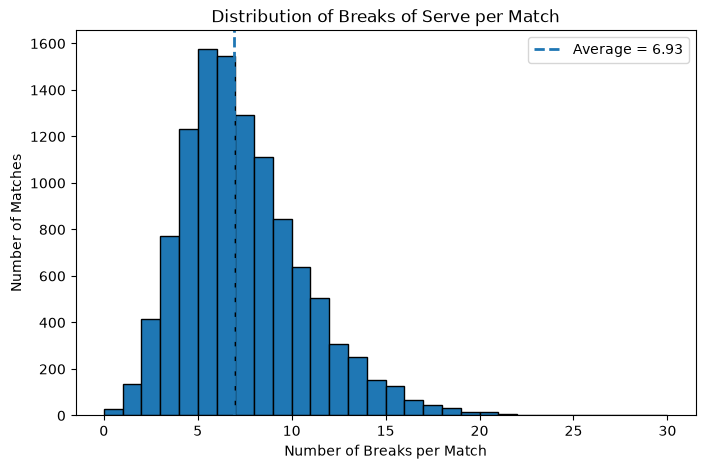

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    breaks_per_match["breaks"],
    bins=range(
        int(breaks_per_match["breaks"].min()),
        int(breaks_per_match["breaks"].max()) + 2
    ),
    edgecolor="black"
)

plt.axvline(
    average_breaks,
    linestyle="--",
    linewidth=2,
    label=f"Average = {average_breaks:.2f}"
)

plt.xlabel("Number of Breaks per Match")
plt.ylabel("Number of Matches")
plt.title("Distribution of Breaks of Serve per Match")
plt.legend()

plt.show()

After removing repeated game-level snapshots and keeping the latest available record for each game, the average number of breaks of serve was calculated across matches. The results show that a tennis match contains 6.93 breaks of serve on average. The distribution plot also provides additional insight into how the number of breaks varies across matches.